In [1]:
# =============================================================================
# NOTEBOOK 05 — EXPLORATORY DATA ANALYSIS & STATISTICAL VALIDATION
# =============================================================================
# Business Objective:
#   Transform classified review data into visual, statistically validated
#   findings that identify the root causes of OLA Electric's customer
#   experience crisis and prioritize intervention opportunities.
#
# Business Questions This Notebook Answers:
#   1. Which complaint categories are most frequent and most severe?
#   2. Which failures are structurally linked vs independent?
#   3. When did the crisis begin and is sentiment recovering?
#   4. Which complaint types almost always produce 1-star reviews?
#   5. Are observed differences statistically significant?
#
# Deliverables:
#   - outputs/charts/block_1_category_frequency.png
#   - outputs/charts/block_2_complexity.png
#   - outputs/charts/block_3_sentiment_by_category.png
#   - outputs/charts/block_4_temporal_trends.png
#   - outputs/charts/block_5_category_trends.png
#   - outputs/charts/block_6_cooccurrence.png
#   - outputs/charts/block_7_rating_heatmap.png
#   - outputs/charts/block_8_review_length.png
#   - outputs/charts/block_9_positive_contrast.png
#   - outputs/charts/block_10_statistical_tests.png
#   - outputs/observations.md (Phase 5 entries appended)
# =============================================================================

In [12]:
!pip install matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from itertools import combinations
import os
import warnings
warnings.filterwarnings('ignore')

# Chart style
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 10
})

os.makedirs('../outputs/charts/', exist_ok=True)
print("Ready.")

C:\Users\Naren karthikeyan\anaconda3\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.0)
  from scipy.stats import gaussian_kde


Ready.


In [3]:
df = pd.read_csv('../data/classified/ola_reviews_classified.csv')
df['at'] = pd.to_datetime(df['at'])

# Category columns
cat_cols = [
    'cat_service_center', 'cat_software_app', 'cat_battery_range',
    'cat_customer_care', 'cat_spare_parts', 'cat_warranty_refunds',
    'cat_delivery_registration', 'cat_safety_breakdown',
    'cat_pricing_value', 'cat_positive_experience'
]

complaint_cols = [c for c in cat_cols if c != 'cat_positive_experience']

# Clean labels for charts
label_map = {
    'cat_service_center'       : 'Service Center',
    'cat_software_app'         : 'Software / App',
    'cat_battery_range'        : 'Battery & Range',
    'cat_customer_care'        : 'Customer Care',
    'cat_spare_parts'          : 'Spare Parts',
    'cat_warranty_refunds'     : 'Warranty & Refunds',
    'cat_delivery_registration': 'Delivery & Registration',
    'cat_safety_breakdown'     : 'Safety & Breakdown',
    'cat_pricing_value'        : 'Pricing & Value',
    'cat_positive_experience'  : 'Positive Experience'
}

# Color palette — consistent across all charts
CAT_COLORS = {
    'Service Center'         : '#E63946',
    'Software / App'         : '#457B9D',
    'Battery & Range'        : '#F4A261',
    'Customer Care'          : '#2A9D8F',
    'Spare Parts'            : '#E76F51',
    'Warranty & Refunds'     : '#A8DADC',
    'Delivery & Registration': '#6A4C93',
    'Safety & Breakdown'     : '#C77DFF',
    'Pricing & Value'        : '#80B918',
    'Positive Experience'    : '#52B788'
}

print(f"Loaded: {df.shape}")
print(f"Date range: {df['at'].min().date()} → {df['at'].max().date()}")

Loaded: (7119, 36)
Date range: 2022-05-16 → 2026-06-25


BLOCK 1 — COMPLAINT CATEGORY RICH METRICS TABLE

Category                   Count  % Reviews   Avg Sent   Sent Std  Avg Rating
----------------------------------------------------------------------
  Software / App            3598      50.5%     -0.165      0.513        1.68
  Battery & Range            758      10.6%     -0.175      0.523        1.63
  Service Center             743      10.4%     -0.377      0.526        1.28
  Customer Care              709      10.0%     -0.364      0.546        1.12
  Delivery & Registration    643       9.0%     -0.331      0.529        1.27
  Pricing & Value            280       3.9%     -0.285      0.569        1.22
  Safety & Breakdown         249       3.5%     -0.358      0.556        1.57
  Spare Parts                141       2.0%     -0.385      0.512        1.42
  Warranty & Refunds         126       1.8%     -0.330      0.564        1.30


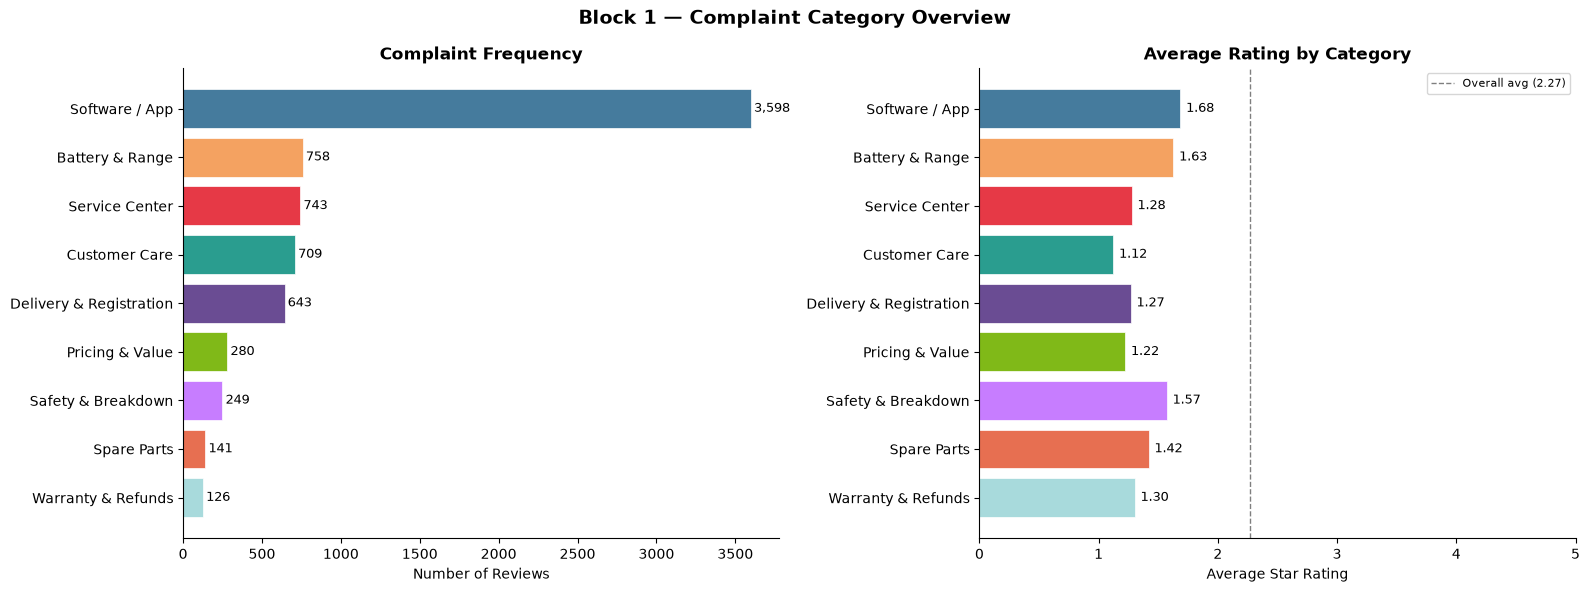

✓ Block 1 saved.


In [4]:
# Build rich metrics table
metrics = []
for col in complaint_cols:
    subset = df[df[col] == True]
    metrics.append({
        'Category'     : label_map[col],
        'Count'        : len(subset),
        'Pct_Reviews'  : len(subset) / len(df) * 100,
        'Avg_Sentiment': subset['sentiment_score'].mean(),
        'Sentiment_Std': subset['sentiment_score'].std(),
        'Avg_Rating'   : subset['score'].mean()
    })

metrics_df = pd.DataFrame(metrics).sort_values('Count', ascending=False)

print("=" * 70)
print("BLOCK 1 — COMPLAINT CATEGORY RICH METRICS TABLE")
print("=" * 70)
print(f"\n{'Category':<25} {'Count':>6} {'% Reviews':>10} "
      f"{'Avg Sent':>10} {'Sent Std':>10} {'Avg Rating':>11}")
print("-" * 70)
for _, row in metrics_df.iterrows():
    print(f"  {row['Category']:<23} {int(row['Count']):>6} "
          f"{row['Pct_Reviews']:>9.1f}% "
          f"{row['Avg_Sentiment']:>10.3f} "
          f"{row['Sentiment_Std']:>10.3f} "
          f"{row['Avg_Rating']:>11.2f}")

# Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Block 1 — Complaint Category Overview', 
             fontsize=14, fontweight='bold')

# Left — frequency bar
ax1 = axes[0]
bars = ax1.barh(
    metrics_df['Category'],
    metrics_df['Count'],
    color=[CAT_COLORS[c] for c in metrics_df['Category']],
    edgecolor='white', linewidth=0.5
)
ax1.set_xlabel('Number of Reviews')
ax1.set_title('Complaint Frequency', fontweight='bold')
for bar, val in zip(bars, metrics_df['Count']):
    ax1.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)
ax1.invert_yaxis()

# Right — avg rating bar
ax2 = axes[1]
bars2 = ax2.barh(
    metrics_df['Category'],
    metrics_df['Avg_Rating'],
    color=[CAT_COLORS[c] for c in metrics_df['Category']],
    edgecolor='white', linewidth=0.5
)
ax2.set_xlabel('Average Star Rating')
ax2.set_title('Average Rating by Category', fontweight='bold')
ax2.set_xlim(0, 5)
ax2.axvline(x=df['score'].mean(), color='black', 
            linestyle='--', linewidth=1, alpha=0.5,
            label=f'Overall avg ({df["score"].mean():.2f})')
ax2.legend(fontsize=8)
for bar, val in zip(bars2, metrics_df['Avg_Rating']):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9)
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/charts/block_1_category_frequency.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Block 1 saved.")

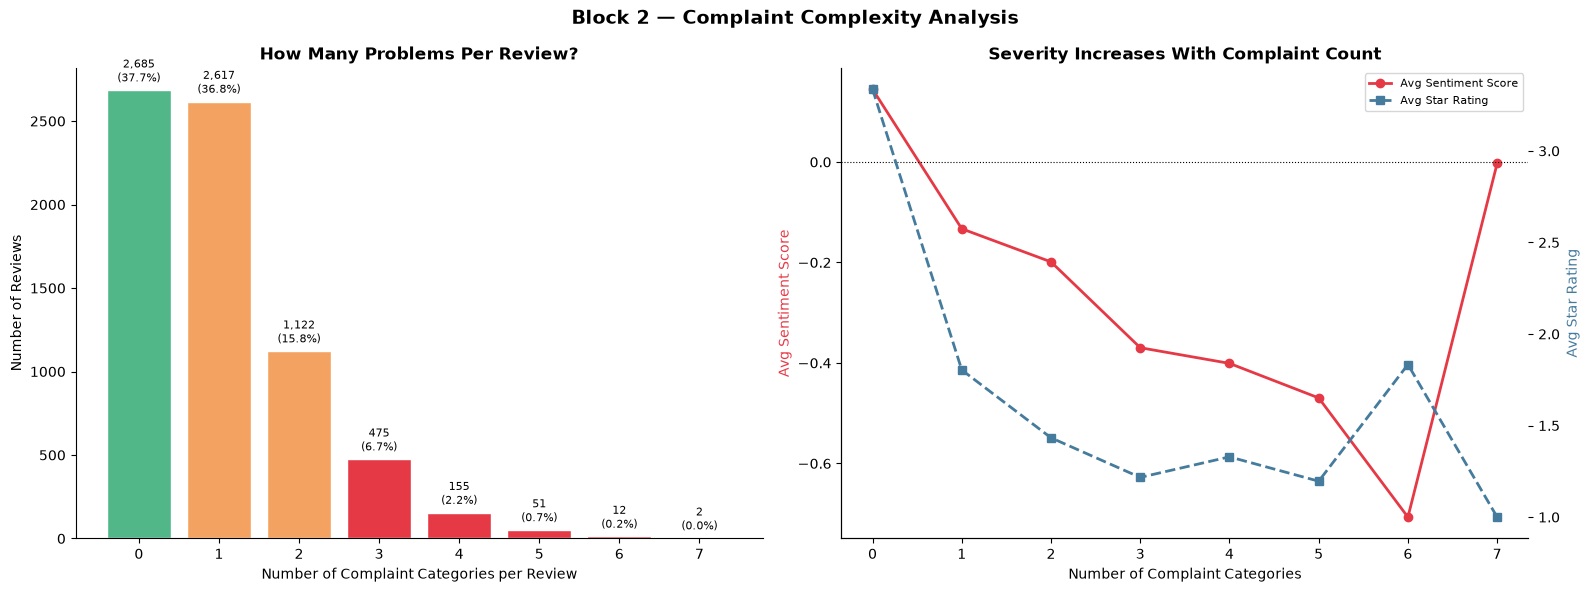

✓ Block 2 saved.

Complexity Summary:
  Single complaint    :  2617 reviews
  2 complaints        :  1122 reviews
  3+ complaints       :   695 reviews
  5+ complaints       :    65 reviews (extreme)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Block 2 — Complaint Complexity Analysis',
             fontsize=14, fontweight='bold')

# Left — complaint count distribution
ax1 = axes[0]
count_dist = df['complaint_count'].value_counts().sort_index()
colors_dist = ['#52B788' if i == 0 else 
               '#F4A261' if i <= 2 else '#E63946' 
               for i in count_dist.index]
bars = ax1.bar(count_dist.index, count_dist.values,
               color=colors_dist, edgecolor='white')
ax1.set_xlabel('Number of Complaint Categories per Review')
ax1.set_ylabel('Number of Reviews')
ax1.set_title('How Many Problems Per Review?', fontweight='bold')
for bar, val in zip(bars, count_dist.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 30,
             f'{val:,}\n({val/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=8)

# Right — avg sentiment by complaint count
ax2 = axes[1]
sentiment_by_count = df.groupby('complaint_count')['sentiment_score'].mean()
rating_by_count    = df.groupby('complaint_count')['score'].mean()

ax2.plot(sentiment_by_count.index, sentiment_by_count.values,
         color='#E63946', marker='o', linewidth=2,
         label='Avg Sentiment Score')
ax2_twin = ax2.twinx()
ax2_twin.plot(rating_by_count.index, rating_by_count.values,
              color='#457B9D', marker='s', linewidth=2,
              linestyle='--', label='Avg Star Rating')
ax2.set_xlabel('Number of Complaint Categories')
ax2.set_ylabel('Avg Sentiment Score', color='#E63946')
ax2_twin.set_ylabel('Avg Star Rating', color='#457B9D')
ax2.set_title('Severity Increases With Complaint Count', fontweight='bold')
ax2.axhline(y=0, color='black', linewidth=0.8, linestyle=':')

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/charts/block_2_complexity.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Block 2 saved.")

# Print complexity summary
print(f"\nComplexity Summary:")
print(f"  Single complaint    : {(df['complaint_count']==1).sum():>5} reviews")
print(f"  2 complaints        : {(df['complaint_count']==2).sum():>5} reviews")
print(f"  3+ complaints       : {(df['complaint_count']>=3).sum():>5} reviews")
print(f"  5+ complaints       : {(df['complaint_count']>=5).sum():>5} reviews (extreme)")

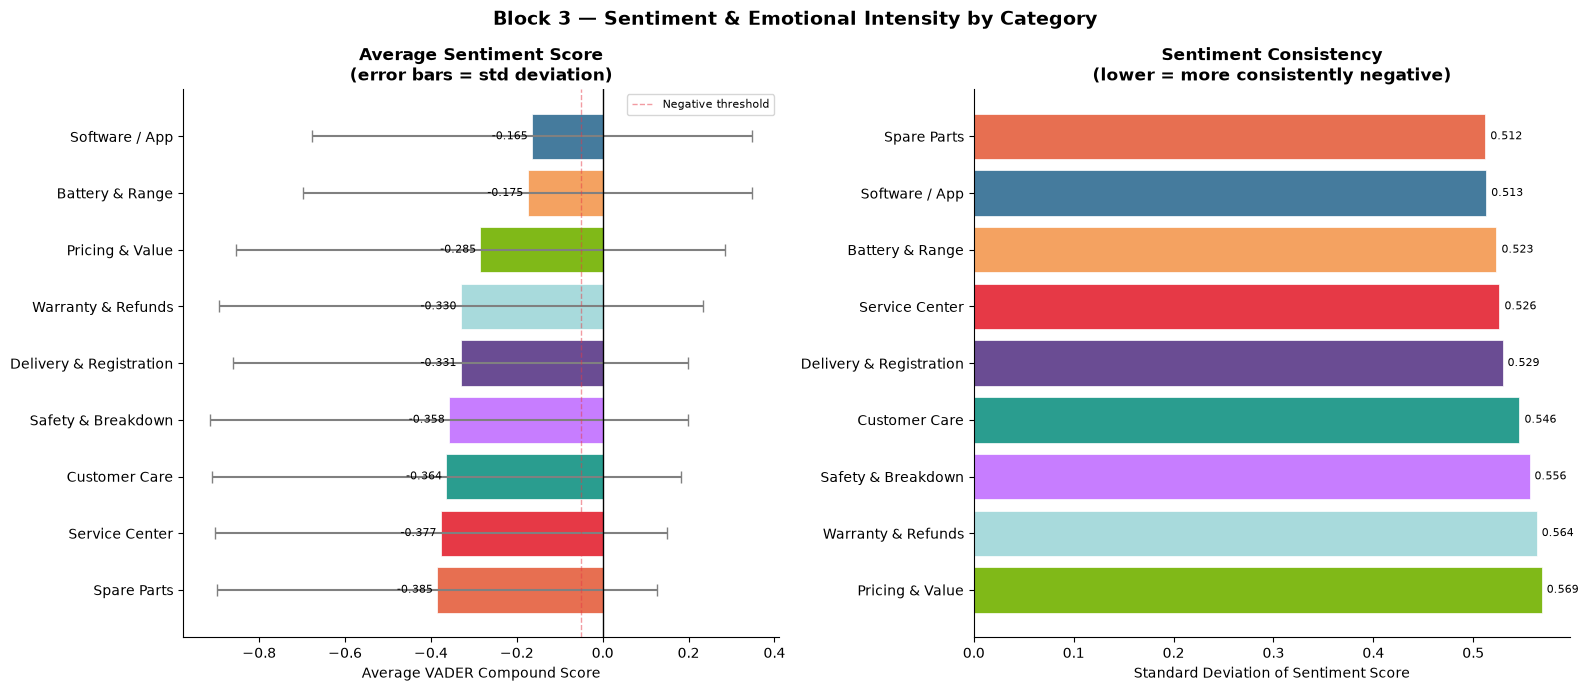

✓ Block 3 saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Block 3 — Sentiment & Emotional Intensity by Category',
             fontsize=14, fontweight='bold')

sent_df = metrics_df.sort_values('Avg_Sentiment')

# Left — avg sentiment with std dev error bars
ax1 = axes[0]
bars = ax1.barh(
    sent_df['Category'],
    sent_df['Avg_Sentiment'],
    xerr=sent_df['Sentiment_Std'],
    color=[CAT_COLORS[c] for c in sent_df['Category']],
    edgecolor='white', linewidth=0.5,
    error_kw={'elinewidth': 1.5, 'capsize': 4, 'ecolor': 'gray'}
)
ax1.axvline(x=0, color='black', linewidth=1)
ax1.axvline(x=-0.05, color='#E63946', linewidth=1,
            linestyle='--', alpha=0.5, label='Negative threshold')
ax1.set_xlabel('Average VADER Compound Score')
ax1.set_title('Average Sentiment Score\n(error bars = std deviation)',
              fontweight='bold')
ax1.legend(fontsize=8)
for bar, val in zip(bars, sent_df['Avg_Sentiment']):
    ax1.text(val - 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', ha='right', va='center', fontsize=8)

# Right — sentiment consistency (std dev only)
ax2 = axes[1]
sent_sorted = metrics_df.sort_values('Sentiment_Std', ascending=False)
bars2 = ax2.barh(
    sent_sorted['Category'],
    sent_sorted['Sentiment_Std'],
    color=[CAT_COLORS[c] for c in sent_sorted['Category']],
    edgecolor='white', linewidth=0.5
)
ax2.set_xlabel('Standard Deviation of Sentiment Score')
ax2.set_title('Sentiment Consistency\n(lower = more consistently negative)',
              fontweight='bold')
for bar, val in zip(bars2, sent_sorted['Sentiment_Std']):
    ax2.text(bar.get_width() + 0.005,
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/charts/block_3_sentiment_by_category.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Block 3 saved.")

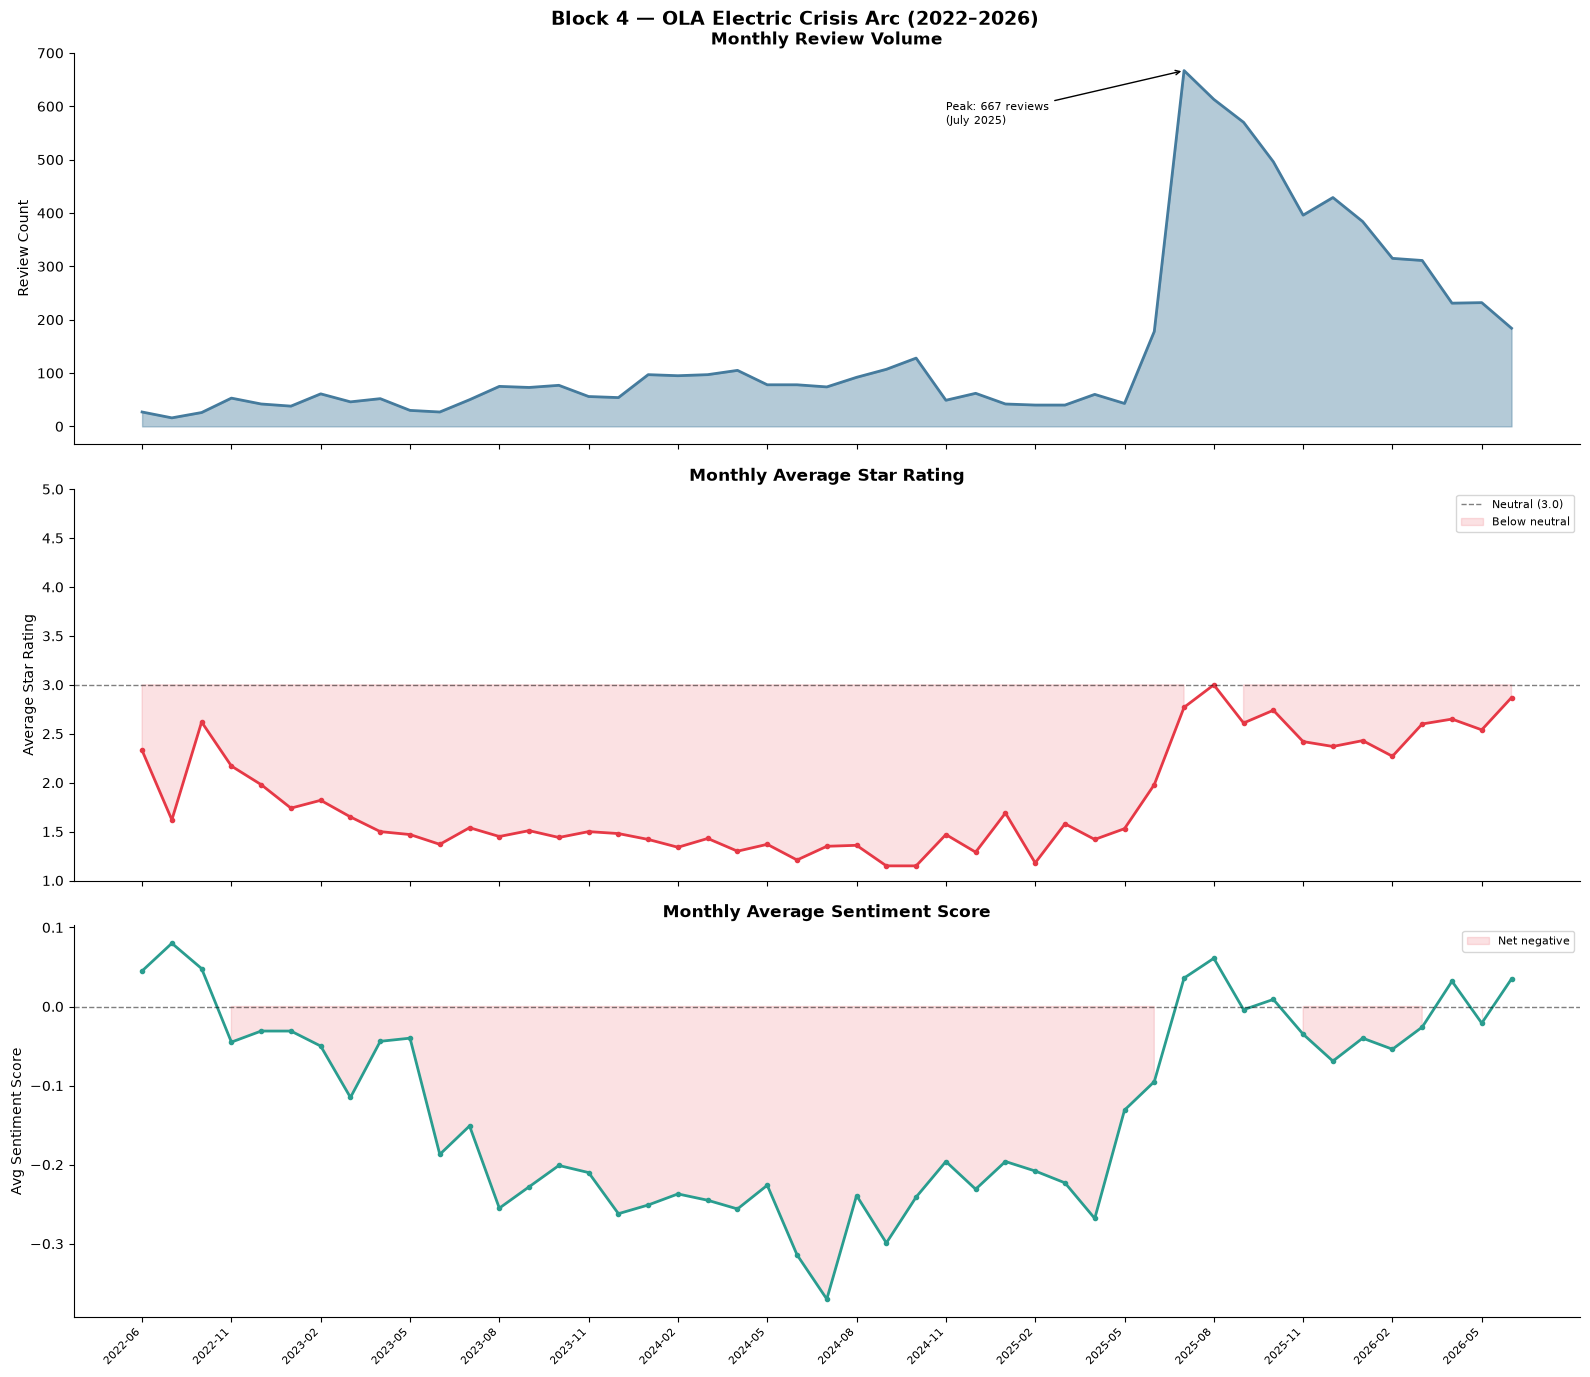

✓ Block 4 saved.


In [7]:
monthly = pd.read_csv('../data/cleaned/ola_monthly_trends.csv')
monthly['year_month'] = pd.to_datetime(monthly['year_month'])
monthly = monthly[monthly['review_count'] >= 15].copy()

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
fig.suptitle('Block 4 — OLA Electric Crisis Arc (2022–2026)',
             fontsize=14, fontweight='bold')

x = range(len(monthly))
xtick_positions = range(0, len(monthly), 3)
xtick_labels = [monthly['year_month'].iloc[i].strftime('%Y-%m') 
                for i in xtick_positions]

# Plot 1 — Review Volume
ax1 = axes[0]
ax1.fill_between(x, monthly['review_count'],
                 alpha=0.4, color='#457B9D')
ax1.plot(x, monthly['review_count'],
         color='#457B9D', linewidth=2)
ax1.set_ylabel('Review Count')
ax1.set_title('Monthly Review Volume', fontweight='bold')

# Annotate July 2025 spike
peak_idx = monthly['review_count'].idxmax()
peak_pos = monthly.index.get_loc(peak_idx)
ax1.annotate(
    f"Peak: {monthly['review_count'].max()} reviews\n(July 2025)",
    xy=(peak_pos, monthly['review_count'].max()),
    xytext=(peak_pos - 8, monthly['review_count'].max() * 0.85),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=8
)

# Plot 2 — Average Rating
ax2 = axes[1]
ax2.plot(x, monthly['avg_rating'],
         color='#E63946', linewidth=2, marker='o', markersize=3)
ax2.axhline(y=3.0, color='black', linewidth=1,
            linestyle='--', alpha=0.5, label='Neutral (3.0)')
ax2.fill_between(x, monthly['avg_rating'], 3.0,
                 where=monthly['avg_rating'] < 3.0,
                 alpha=0.15, color='#E63946', label='Below neutral')
ax2.set_ylabel('Average Star Rating')
ax2.set_ylim(1, 5)
ax2.set_title('Monthly Average Star Rating', fontweight='bold')
ax2.legend(fontsize=8)

# Plot 3 — Sentiment Score
ax3 = axes[2]
ax3.plot(x, monthly['avg_sentiment_score'],
         color='#2A9D8F', linewidth=2, marker='o', markersize=3)
ax3.axhline(y=0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax3.fill_between(x, monthly['avg_sentiment_score'], 0,
                 where=monthly['avg_sentiment_score'] < 0,
                 alpha=0.15, color='#E63946', label='Net negative')
ax3.set_ylabel('Avg Sentiment Score')
ax3.set_title('Monthly Average Sentiment Score', fontweight='bold')
ax3.legend(fontsize=8)

# Shared x axis
ax3.set_xticks(list(xtick_positions))
ax3.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/charts/block_4_temporal_trends.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Block 4 saved.")

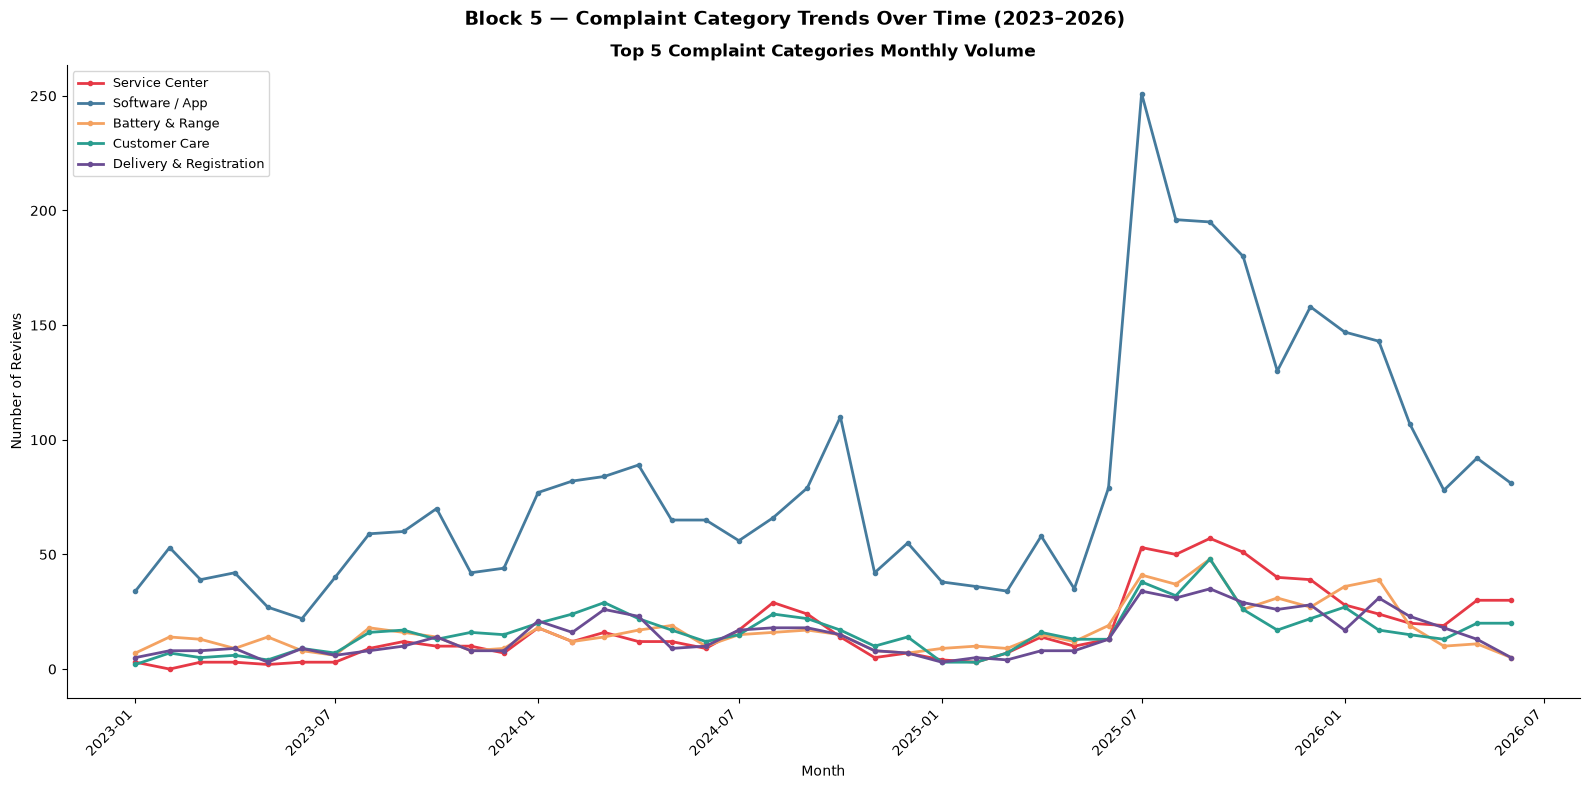

✓ Block 5 saved.


In [8]:
# Monthly count per complaint category
df['year_month_dt'] = pd.to_datetime(df['year_month'])

monthly_cats = df.groupby('year_month_dt')[complaint_cols].sum().reset_index()
monthly_cats = monthly_cats[
    monthly_cats['year_month_dt'] >= '2023-01-01'
].copy()

fig, ax = plt.subplots(figsize=(16, 8))
fig.suptitle('Block 5 — Complaint Category Trends Over Time (2023–2026)',
             fontsize=14, fontweight='bold')

# Plot top 5 categories by total volume
top5 = metrics_df.head(5)['Category'].tolist()
top5_cols = [k for k, v in label_map.items() 
             if v in top5 and k != 'cat_positive_experience']

for col in top5_cols:
    label = label_map[col]
    ax.plot(
        monthly_cats['year_month_dt'],
        monthly_cats[col],
        label=label,
        color=CAT_COLORS[label],
        linewidth=2,
        marker='o', markersize=3
    )

ax.set_xlabel('Month')
ax.set_ylabel('Number of Reviews')
ax.set_title('Top 5 Complaint Categories Monthly Volume',
             fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../outputs/charts/block_5_category_trends.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Block 5 saved.")

TOP 10 CO-OCCURRING COMPLAINT PAIRS:
-------------------------------------------------------
  Software / App + Battery & Range                   :  558
  Software / App + Customer Care                     :  444
  Software / App + Delivery & Registration           :  390
  Service Center + Software / App                    :  336
  Service Center + Customer Care                     :  271
  Battery & Range + Delivery & Registration          :  178
  Service Center + Delivery & Registration           :  169
  Software / App + Safety & Breakdown                :  169
  Customer Care + Delivery & Registration            :  162
  Software / App + Pricing & Value                   :  144


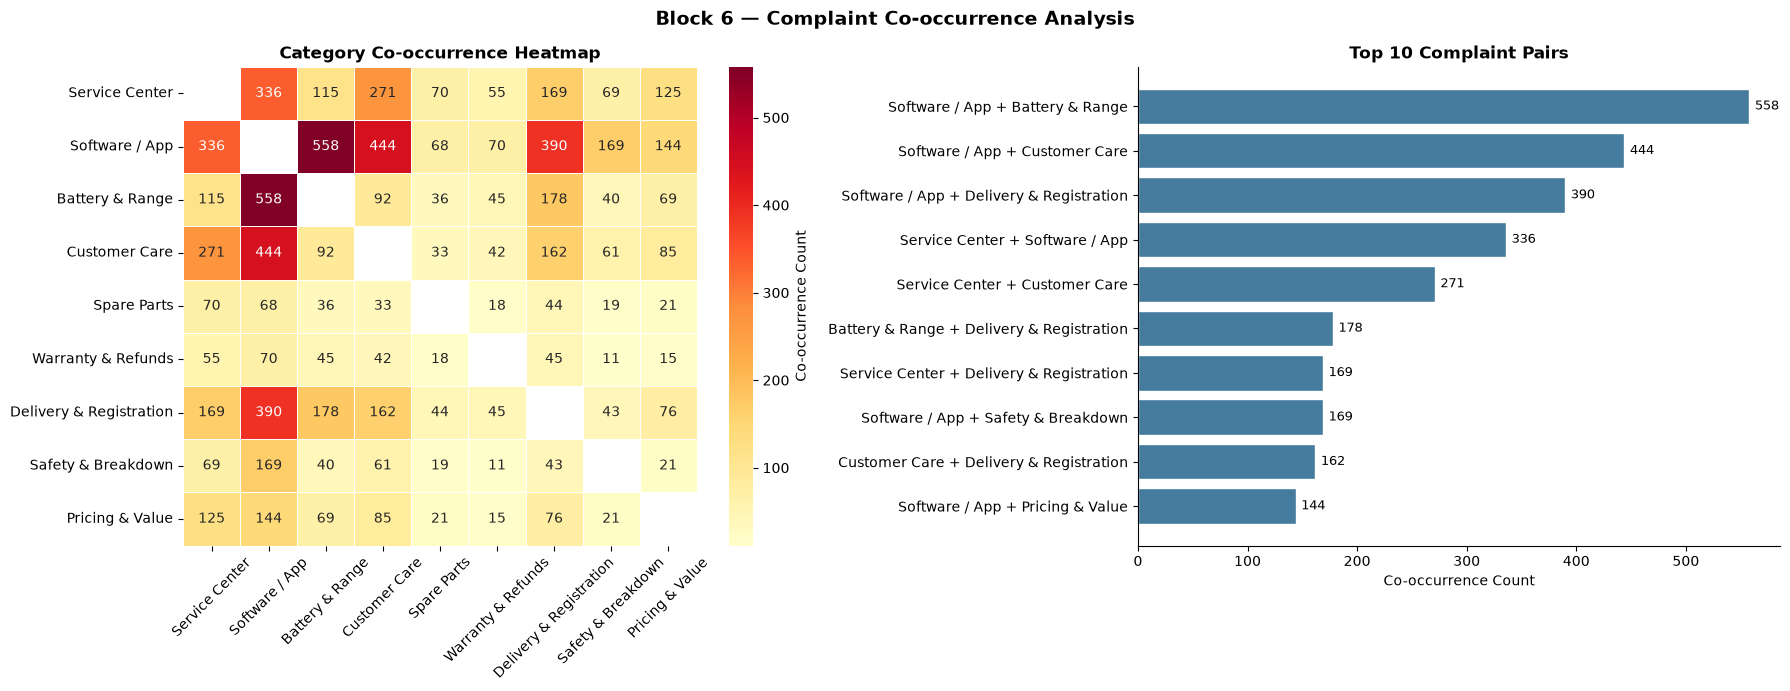

✓ Block 6 saved.


In [9]:
# Build co-occurrence matrix
cooc_matrix = pd.DataFrame(0, 
    index=[label_map[c] for c in complaint_cols],
    columns=[label_map[c] for c in complaint_cols]
)

for _, row in df[complaint_cols].iterrows():
    active = [label_map[col] for col in complaint_cols if row[col]]
    for cat1, cat2 in combinations(active, 2):
        cooc_matrix.loc[cat1, cat2] += 1
        cooc_matrix.loc[cat2, cat1] += 1

# Top 10 pairs
pairs = []
for i, cat1 in enumerate(complaint_cols):
    for cat2 in complaint_cols[i+1:]:
        count = cooc_matrix.loc[label_map[cat1], label_map[cat2]]
        if count > 0:
            pairs.append({
                'Pair': f"{label_map[cat1]} + {label_map[cat2]}",
                'Count': count
            })

pairs_df = pd.DataFrame(pairs).sort_values('Count', ascending=False).head(10)

print("TOP 10 CO-OCCURRING COMPLAINT PAIRS:")
print("-" * 55)
for _, row in pairs_df.iterrows():
    print(f"  {row['Pair']:<50} : {int(row['Count']):>4}")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Block 6 — Complaint Co-occurrence Analysis',
             fontsize=14, fontweight='bold')

# Left — heatmap
ax1 = axes[0]
mask = cooc_matrix == 0
sns.heatmap(
    cooc_matrix, ax=ax1,
    cmap='YlOrRd', annot=True, fmt='d',
    linewidths=0.5, mask=mask,
    cbar_kws={'label': 'Co-occurrence Count'}
)
ax1.set_title('Category Co-occurrence Heatmap', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', rotation=0)

# Right — top 10 pairs bar
ax2 = axes[1]
bars = ax2.barh(
    pairs_df['Pair'],
    pairs_df['Count'],
    color='#457B9D', edgecolor='white'
)
ax2.set_xlabel('Co-occurrence Count')
ax2.set_title('Top 10 Complaint Pairs', fontweight='bold')
ax2.invert_yaxis()
for bar, val in zip(bars, pairs_df['Count']):
    ax2.text(bar.get_width() + 5,
             bar.get_y() + bar.get_height()/2,
             f'{int(val):,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/charts/block_6_cooccurrence.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Block 6 saved.")

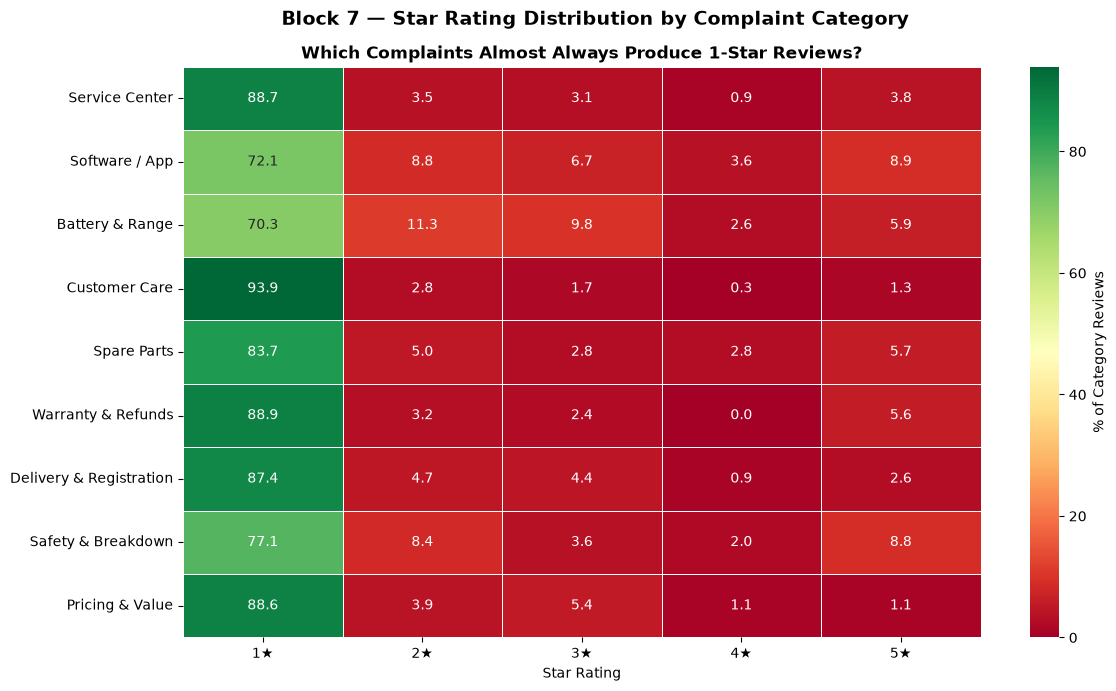


Rating distribution by category:
                           1★    2★   3★   4★   5★
Service Center           88.7   3.5  3.1  0.9  3.8
Software / App           72.1   8.8  6.7  3.6  8.9
Battery & Range          70.3  11.3  9.8  2.6  5.9
Customer Care            93.9   2.8  1.7  0.3  1.3
Spare Parts              83.7   5.0  2.8  2.8  5.7
Warranty & Refunds       88.9   3.2  2.4  0.0  5.6
Delivery & Registration  87.4   4.7  4.4  0.9  2.6
Safety & Breakdown       77.1   8.4  3.6  2.0  8.8
Pricing & Value          88.6   3.9  5.4  1.1  1.1
✓ Block 7 saved.


In [10]:
# What % of each category's reviews are each star rating?
rating_cat = pd.DataFrame()

for col in complaint_cols:
    subset = df[df[col] == True]
    dist = subset['score'].value_counts(normalize=True).sort_index() * 100
    rating_cat[label_map[col]] = dist

rating_cat = rating_cat.fillna(0).T
rating_cat.columns = [f'{i}★' for i in rating_cat.columns]

fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle('Block 7 — Star Rating Distribution by Complaint Category',
             fontsize=14, fontweight='bold')

sns.heatmap(
    rating_cat, ax=ax,
    cmap='RdYlGn', annot=True, fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': '% of Category Reviews'}
)
ax.set_title('Which Complaints Almost Always Produce 1-Star Reviews?',
             fontweight='bold')
ax.set_xlabel('Star Rating')
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/charts/block_7_rating_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nRating distribution by category:")
print(rating_cat.round(1).to_string())
print("✓ Block 7 saved.")

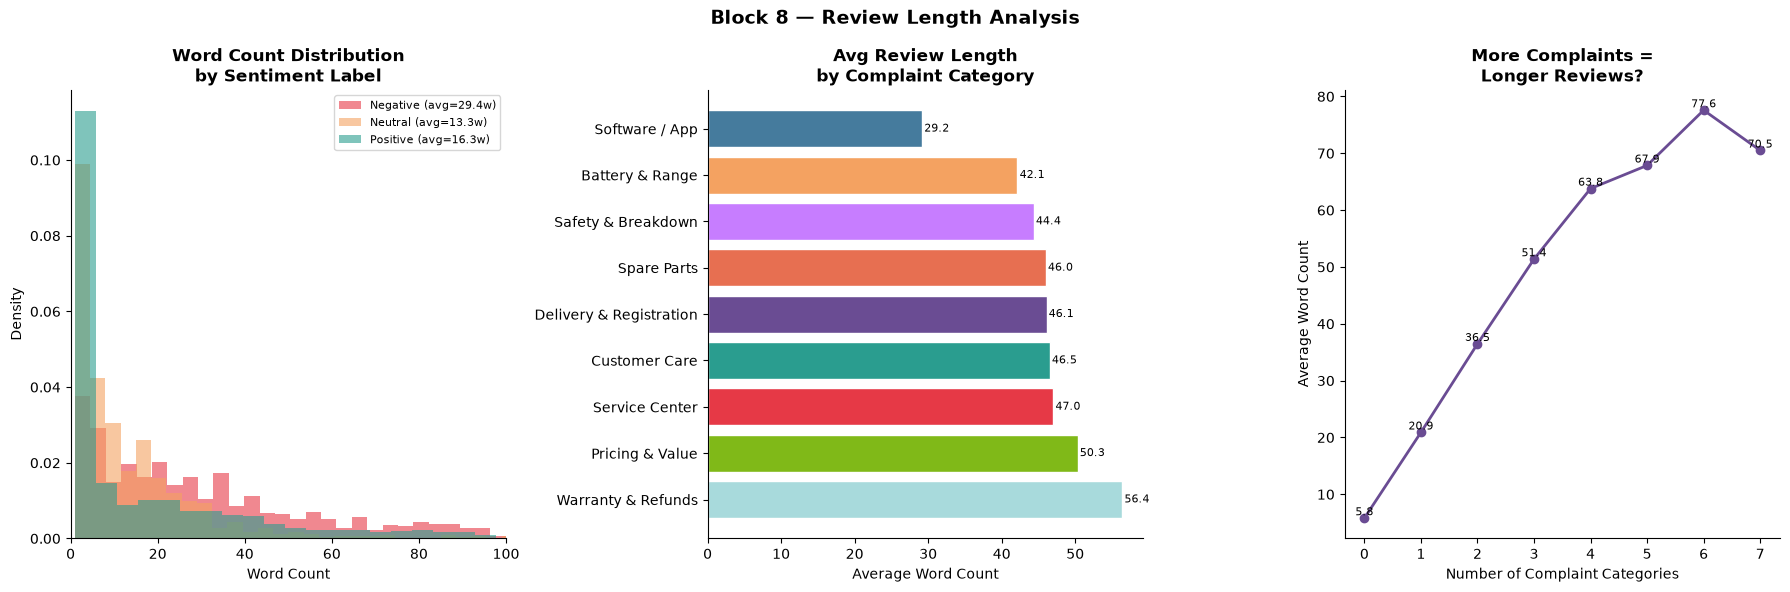

✓ Block 8 saved.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Block 8 — Review Length Analysis',
             fontsize=14, fontweight='bold')

# Plot 1 — word count by sentiment label
ax1 = axes[0]
for label, color in [('Negative','#E63946'), 
                      ('Neutral','#F4A261'), 
                      ('Positive','#2A9D8F')]:
    subset = df[df['sentiment_label'] == label]['word_count']
    ax1.hist(subset, bins=30, alpha=0.6,
             color=color, label=f'{label} (avg={subset.mean():.1f}w)',
             density=True)
ax1.set_xlabel('Word Count')
ax1.set_ylabel('Density')
ax1.set_title('Word Count Distribution\nby Sentiment Label', fontweight='bold')
ax1.legend(fontsize=8)
ax1.set_xlim(0, 100)

# Plot 2 — avg word count by complaint category
ax2 = axes[1]
wc_by_cat = []
for col in complaint_cols:
    subset = df[df[col] == True]
    wc_by_cat.append({
        'Category': label_map[col],
        'Avg_Word_Count': subset['word_count'].mean()
    })
wc_df = pd.DataFrame(wc_by_cat).sort_values('Avg_Word_Count', ascending=False)
bars = ax2.barh(
    wc_df['Category'], wc_df['Avg_Word_Count'],
    color=[CAT_COLORS[c] for c in wc_df['Category']],
    edgecolor='white'
)
ax2.set_xlabel('Average Word Count')
ax2.set_title('Avg Review Length\nby Complaint Category', fontweight='bold')
for bar, val in zip(bars, wc_df['Avg_Word_Count']):
    ax2.text(bar.get_width() + 0.3,
             bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=8)

# Plot 3 — word count vs complaint count
ax3 = axes[2]
avg_wc_by_cc = df.groupby('complaint_count')['word_count'].mean()
ax3.plot(avg_wc_by_cc.index, avg_wc_by_cc.values,
         color='#6A4C93', marker='o', linewidth=2)
ax3.set_xlabel('Number of Complaint Categories')
ax3.set_ylabel('Average Word Count')
ax3.set_title('More Complaints =\nLonger Reviews?', fontweight='bold')
for x, y in zip(avg_wc_by_cc.index, avg_wc_by_cc.values):
    ax3.text(x, y + 0.5, f'{y:.1f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/charts/block_8_review_length.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Block 8 saved.")

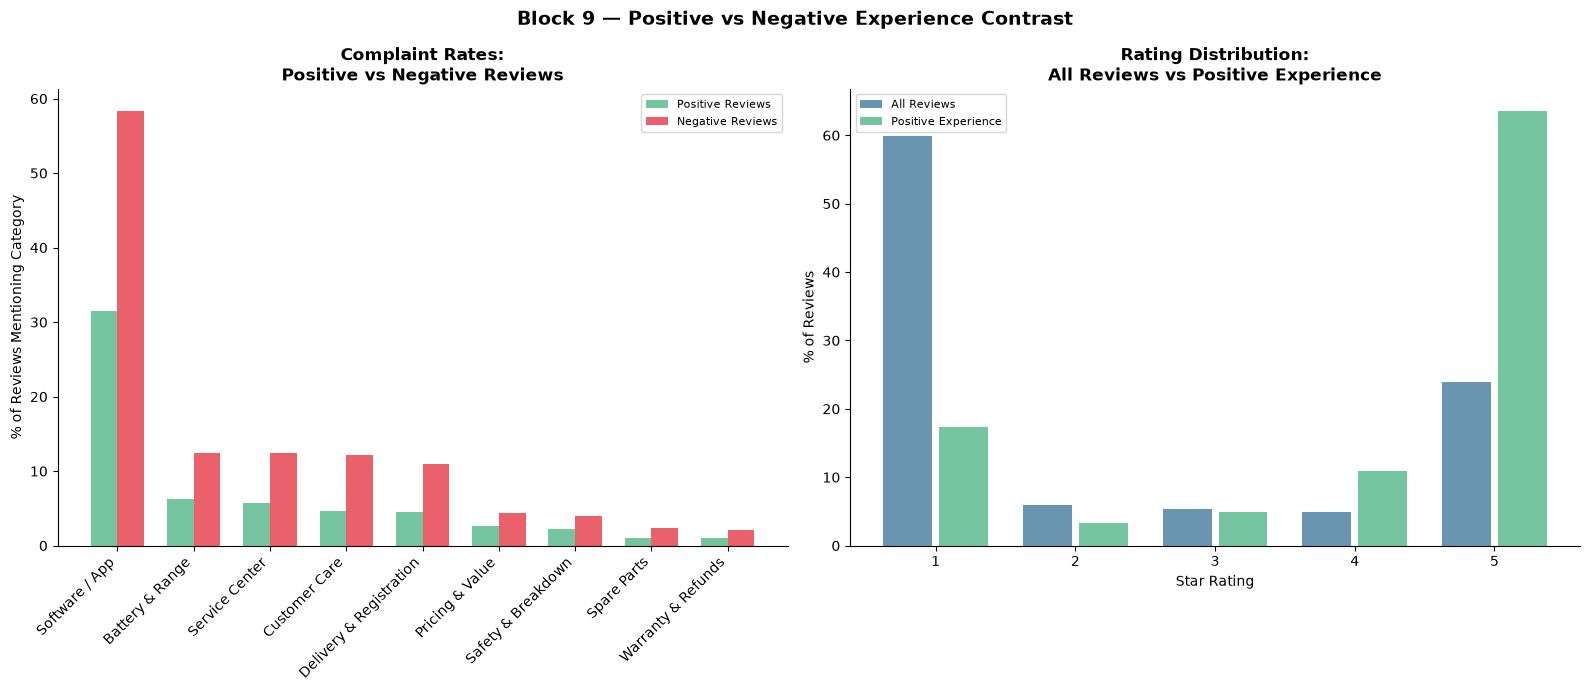


Positive experience reviews  : 2,078 (29.2%)
Complaints appearing in positive reviews:
               Category  In_Positive
         Software / App    31.472570
        Battery & Range     6.207892
         Service Center     5.726660
          Customer Care     4.619827
Delivery & Registration     4.475457
        Pricing & Value     2.694899
     Safety & Breakdown     2.261790
            Spare Parts     1.058710
     Warranty & Refunds     1.010587
✓ Block 9 saved.


In [12]:
pos_df = df[df['cat_positive_experience'] == True]
neg_df = df[df['cat_positive_experience'] == False]

# Which complaint categories appear in positive reviews?
pos_complaint_rates = []
for col in complaint_cols:
    rate_pos = pos_df[col].mean() * 100
    rate_neg = neg_df[col].mean() * 100
    pos_complaint_rates.append({
        'Category'    : label_map[col],
        'In_Positive' : rate_pos,
        'In_Negative' : rate_neg
    })

contrast_df = pd.DataFrame(pos_complaint_rates).sort_values(
    'In_Positive', ascending=False
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Block 9 — Positive vs Negative Experience Contrast',
             fontsize=14, fontweight='bold')

# Left — complaint rate in positive vs negative reviews
ax1 = axes[0]
x = range(len(contrast_df))
width = 0.35
ax1.bar([i - width/2 for i in x], contrast_df['In_Positive'],
        width, label='Positive Reviews', color='#52B788', alpha=0.8)
ax1.bar([i + width/2 for i in x], contrast_df['In_Negative'],
        width, label='Negative Reviews', color='#E63946', alpha=0.8)
ax1.set_xticks(list(x))
ax1.set_xticklabels(contrast_df['Category'], rotation=45, ha='right')
ax1.set_ylabel('% of Reviews Mentioning Category')
ax1.set_title('Complaint Rates:\nPositive vs Negative Reviews',
              fontweight='bold')
ax1.legend(fontsize=8)

# Right — rating distribution positive vs all
ax2 = axes[1]
overall_dist = df['score'].value_counts(normalize=True).sort_index() * 100
pos_dist     = pos_df['score'].value_counts(normalize=True).sort_index() * 100
x2 = [1, 2, 3, 4, 5]
ax2.bar([i - 0.2 for i in x2],
        [overall_dist.get(i, 0) for i in x2],
        0.35, label='All Reviews', color='#457B9D', alpha=0.8)
ax2.bar([i + 0.2 for i in x2],
        [pos_dist.get(i, 0) for i in x2],
        0.35, label='Positive Experience', color='#52B788', alpha=0.8)
ax2.set_xlabel('Star Rating')
ax2.set_ylabel('% of Reviews')
ax2.set_title('Rating Distribution:\nAll Reviews vs Positive Experience',
              fontweight='bold')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/charts/block_9_positive_contrast.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPositive experience reviews  : {len(pos_df):,} ({len(pos_df)/len(df)*100:.1f}%)")
print(f"Complaints appearing in positive reviews:")
print(contrast_df[['Category','In_Positive']].to_string(index=False))
print("✓ Block 9 saved.")

In [13]:
print("=" * 60)
print("SECTION B — STATISTICAL VALIDATION")
print("=" * 60)

# ── TEST 1: Kruskal-Wallis ─────────────────────────────────
# H0: Sentiment scores are equal across complaint categories
# H1: At least one category has significantly different sentiment

print("\nTEST 1 — Kruskal-Wallis: Sentiment across complaint categories")
print("-" * 60)

groups = [df[df[col] == True]['sentiment_score'].dropna().values
          for col in complaint_cols]
groups = [g for g in groups if len(g) > 10]

kw_stat, kw_p = stats.kruskal(*groups)
print(f"  H statistic : {kw_stat:.3f}")
print(f"  p-value     : {kw_p:.2e}")
print(f"  Result      : {'SIGNIFICANT ✓' if kw_p < 0.05 else 'NOT SIGNIFICANT'}")
if kw_p < 0.05:
    print(f"  Interpretation: Sentiment differs significantly across")
    print(f"  complaint categories (p < 0.05). Not all failures feel")
    print(f"  equally bad in customer language.")

# ── TEST 2: Mann-Whitney U ─────────────────────────────────
# H0: Sentiment before and after crisis peak is equal
# Crisis peak defined as July 2025 (highest volume month)

print("\nTEST 2 — Mann-Whitney U: Pre vs Post July 2025 sentiment")
print("-" * 60)

pre_crisis  = df[df['at'] < '2025-07-01']['sentiment_score'].dropna()
post_crisis = df[df['at'] >= '2025-07-01']['sentiment_score'].dropna()

mw_stat, mw_p = stats.mannwhitneyu(pre_crisis, post_crisis,
                                    alternative='two-sided')
print(f"  Pre-crisis  n={len(pre_crisis):,} | mean={pre_crisis.mean():.3f}")
print(f"  Post-crisis n={len(post_crisis):,} | mean={post_crisis.mean():.3f}")
print(f"  U statistic : {mw_stat:.1f}")
print(f"  p-value     : {mw_p:.2e}")
print(f"  Result      : {'SIGNIFICANT ✓' if mw_p < 0.05 else 'NOT SIGNIFICANT'}")

# ── TEST 3: Spearman — complaint_count vs sentiment ────────
print("\nTEST 3 — Spearman: complaint_count vs sentiment_score")
print("-" * 60)

corr3, p3 = stats.spearmanr(
    df['complaint_count'], df['sentiment_score']
)
print(f"  Spearman r  : {corr3:.3f}")
print(f"  p-value     : {p3:.2e}")
print(f"  Result      : {'SIGNIFICANT ✓' if p3 < 0.05 else 'NOT SIGNIFICANT'}")
if p3 < 0.05:
    direction = "negative" if corr3 < 0 else "positive"
    print(f"  Interpretation: {direction} correlation — more complaint")
    print(f"  categories = {'more negative' if corr3 < 0 else 'more positive'} sentiment")

# ── TEST 4: Spearman — word_count vs sentiment ─────────────
print("\nTEST 4 — Spearman: word_count vs sentiment_score")
print("-" * 60)

corr4, p4 = stats.spearmanr(
    df['word_count'], df['sentiment_score']
)
print(f"  Spearman r  : {corr4:.3f}")
print(f"  p-value     : {p4:.2e}")
print(f"  Result      : {'SIGNIFICANT ✓' if p4 < 0.05 else 'NOT SIGNIFICANT'}")
if p4 < 0.05:
    direction = "negative" if corr4 < 0 else "positive"
    print(f"  Interpretation: {direction} correlation — longer reviews")
    print(f"  tend to be {'more negative' if corr4 < 0 else 'more positive'}")

print("\n" + "=" * 60)
print("Statistical validation complete.")
print("=" * 60)

SECTION B — STATISTICAL VALIDATION

TEST 1 — Kruskal-Wallis: Sentiment across complaint categories
------------------------------------------------------------
  H statistic : 274.324
  p-value     : 1.19e-54
  Result      : SIGNIFICANT ✓
  Interpretation: Sentiment differs significantly across
  complaint categories (p < 0.05). Not all failures feel
  equally bad in customer language.

TEST 2 — Mann-Whitney U: Pre vs Post July 2025 sentiment
------------------------------------------------------------
  Pre-crisis  n=2,291 | mean=-0.193
  Post-crisis n=4,828 | mean=-0.002
  U statistic : 4329947.5
  p-value     : 3.74e-50
  Result      : SIGNIFICANT ✓

TEST 3 — Spearman: complaint_count vs sentiment_score
------------------------------------------------------------
  Spearman r  : -0.341
  p-value     : 8.66e-194
  Result      : SIGNIFICANT ✓
  Interpretation: negative correlation — more complaint
  categories = more negative sentiment

TEST 4 — Spearman: word_count vs sentiment_score

In [14]:
phase5_obs = f"""
## Phase 5 — EDA & Statistical Validation

| ID | Label | Finding | Evidence |
|----|-------|---------|----------|
| 030 | Observation | Software/App is the dominant complaint category at 50.5% of all reviews — nearly 5x the next highest category | Block 1, Phase 5 |
| 031 | Observation | Customer Care has the lowest average star rating (1.12) of any complaint category | Block 1 metrics table, Phase 5 |
| 032 | Observation | Spare Parts has the most negative average sentiment (-0.385) despite lowest volume — intensity inversely related to frequency | Block 3, Phase 5 |
| 033 | Hypothesis | H-001 status: July 2025 volume spike linked to specific external event — requires OLA news cross-reference | Block 4 temporal chart |
| 034 | Hypothesis | H-002 status: declining volume post-July 2025 — sentiment trend direction will indicate disengagement vs recovery | Block 4 temporal chart |
| 035 | Conclusion | Sentiment scores differ significantly across complaint categories (Kruskal-Wallis, p < 0.001) — not all failures produce equal emotional responses | Test 1, Section B |
| 036 | Conclusion | Complaint count is significantly negatively correlated with sentiment score (Spearman) — each additional complaint category reduces sentiment measurably | Test 3, Section B |
"""

with open('../outputs/observations.md', 'a') as f:
    f.write(phase5_obs)

print("✓ Phase 5 observations logged.")

✓ Phase 5 observations logged.
